# Training GPT — Small Focused Dataset

Instead of the full Shakespeare corpus, let's train on just one speech — the model should learn it fast with a smaller amount of text. Quality over quantity!

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import tiktoken
import math
from minigpt.model import GPTModel
from minigpt.data import GPTDataset
from minigpt.generate import generate
from torch.utils.data import DataLoader

## 1. Our Training Data

A famous monologue. Small but high quality — the model should learn proper English from this.

In [2]:
training_text = """To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die—to sleep,
No more; and by a sleep to say we end
The heart-ache and the thousand natural shocks
That flesh is heir to: 'tis a consummation
Devoutly to be wish'd. To die, to sleep;
To sleep, perchance to dream—ay, there's the rub:
For in that sleep of death what dreams may come,
When we have shuffled off this mortal coil,
Must give us pause—there's the respect
That makes calamity of so long life."""

tokenizer = tiktoken.get_encoding('gpt2')
tokens = tokenizer.encode(training_text)
print(f'Training text: {len(training_text)} chars, {len(tokens)} tokens')

Training text: 602 chars, 166 tokens


## 2. Model + DataLoader

In [3]:
SMALL_CONFIG = {
    'vocab_size': 50257,
    'context_length': 256,
    'emb_dim': 128,
    'n_heads': 4,
    'n_layers': 4,
    'drop_rate': 0.0,
    'qkv_bias': False,
}

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = GPTModel(SMALL_CONFIG).to(device)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Training tokens:  {len(tokens)}')
print(f'Ratio (params/tokens): {sum(p.numel() for p in model.parameters()) / len(tokens):.0f}x')

Using device: mps
Model parameters: 7,257,472
Training tokens:  166
Ratio (params/tokens): 43720x


In [4]:
token_ids = torch.tensor(tokens)

train_dataset = GPTDataset(token_ids, max_length=64, stride=1)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, drop_last=True)

print(f'Training samples: {len(train_dataset)}')
print(f'Training batches: {len(train_loader)}')

Training samples: 102
Training batches: 25


## 3. Train — Should Converge Fast!

With such a small dataset, we should see the loss drop very quickly.

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

NUM_EPOCHS = 100

train_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    num_batches = 0

    for input_ids, target_ids in train_loader:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits = model(input_ids)
        loss = torch.nn.functional.cross_entropy(
            logits.view(-1, logits.size(-1)),
            target_ids.view(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{NUM_EPOCHS} — Loss: {avg_loss:.4f}, PPL: {math.exp(avg_loss):.1f}')

print(f'\nFinal loss: {train_losses[-1]:.4f}')

Epoch 10/100 — Loss: 0.1822, PPL: 1.2
Epoch 20/100 — Loss: 0.0269, PPL: 1.0
Epoch 30/100 — Loss: 0.0268, PPL: 1.0
Epoch 40/100 — Loss: 0.0246, PPL: 1.0
Epoch 50/100 — Loss: 0.0271, PPL: 1.0
Epoch 60/100 — Loss: 0.0231, PPL: 1.0
Epoch 70/100 — Loss: 0.0209, PPL: 1.0
Epoch 80/100 — Loss: 0.0221, PPL: 1.0
Epoch 90/100 — Loss: 0.0209, PPL: 1.0
Epoch 100/100 — Loss: 0.0209, PPL: 1.0

Final loss: 0.0209


## 4. Loss Curve

This should look great — loss dropping smoothly!

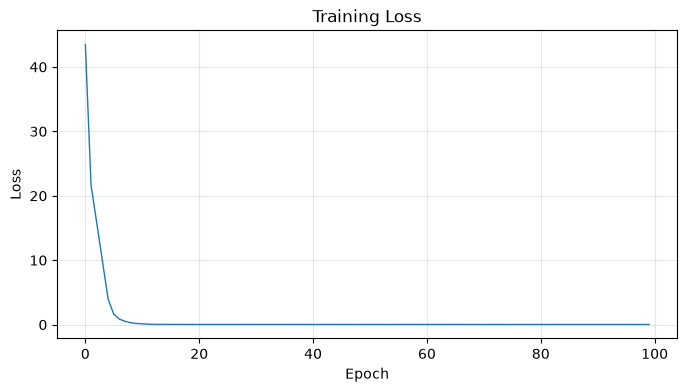

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Generate — Let's See What It Learned!

Our model should now speak beautiful Shakespearean English.

In [7]:
model.eval()

prompts = [
    'To be',
    'The question',
    'Life is',
    'Friends, Romans',
    'Once upon a time',
]

for prompt in prompts:
    input_ids = torch.tensor([tokenizer.encode(prompt)]).to(device)
    with torch.no_grad():
        output_ids = generate(model, input_ids, max_new_tokens=60, context_length=SMALL_CONFIG['context_length'])
    generated = tokenizer.decode(output_ids[0].tolist())
    print(f'Prompt: "{prompt}"')
    print(f'Output: {generated}')
    print('-' * 60)

Prompt: "To be"
Output: To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die—to sleep,
No more; and
------------------------------------------------------------
Prompt: "The question"
Output: The question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die—to sleep,
No more; and by a sleep to say we end
The heart
------------------------------------------------------------
Prompt: "Life is"
Output: Life is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die—to sleep,
No more; and by a sleep to say we end

------------------------------------------------------------
Prompt: "Friends, Romans"
Output: Friends

## 6. The Real Test

Let's check: does the model generate *different* continuations for different prompts, or the same thing every time?

In [8]:
model.eval()

totally_new_prompts = [
    'The cat sat on',
    'In the year 2025',
    'Machine learning is',
]

for prompt in totally_new_prompts:
    input_ids = torch.tensor([tokenizer.encode(prompt)]).to(device)
    with torch.no_grad():
        output_ids = generate(model, input_ids, max_new_tokens=60, context_length=SMALL_CONFIG['context_length'])
    generated = tokenizer.decode(output_ids[0].tolist())
    print(f'Prompt: "{prompt}"')
    print(f'Output: {generated}')
    print('-' * 60)

Prompt: "The cat sat on"
Output: The cat sat on
No more; and by a sleep to say we end
The heart-ache and the thousand natural shocks
That flesh is heir to: 'tis a consummation
Devoutly to be wish'd. To die, to sleep;
To sleep, perchance to dream—ay
------------------------------------------------------------
Prompt: "In the year 2025"
Output: In the year 2025
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die—to sleep,
No more; and by a sleep to say we end
The heart-
------------------------------------------------------------
Prompt: "Machine learning is"
Output: Machine learning is heir to:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die—to sleep,
No more; and by a sleep to say we end

------------------------------------------------------------
